In [1]:
%load_ext autoreload
%autoreload 2

# Prior-dependent belief updates

Results of `scripts/pseudo_decoding/belief_partitions/prior_dependent_updates.py`, the analysis in
`claude_notes/Prior-dependent belief update analysis proposal.md`.

- **neural:** the real pre-stimulus firing rates.
- **beliefs:** the same pipeline run on the 12 belief-state probabilities as 12 units, i.e. the model's prediction.
- **white_noise:** N(0, 1) in each session's real shape, at several split seeds; p should not pile up near 0.

Each value is the mean, across (session, feature) units, of a cell's mean projection onto $u_X$
(each feature's pseudo-population axis scaled to unit length). Error bars are SE across units.

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = "/data/patrick_res/prior_dependent_updates/both_StimOnset"
WHITE_NOISE_SEEDS = [42, 1, 2, 3, 4]

def read(frs_source, name, seed=42):
    seed_str = "" if seed == 42 else f"_seed_{seed}"
    return pd.read_pickle(os.path.join(OUTPUT_DIR, f"prior_dep_updates_{frs_source}{seed_str}_{name}.pickle"))

stats = {src: read(src, "stats") for src in ["neural", "beliefs"]}
cells = {src: read(src, "cells") for src in ["neural", "beliefs"]}

## Tests

One-sided sign-flip tests, flips per (session, feature). `p_holm` is Holm over H1 and H2; the control is outside that family.

In [3]:
cols = ["contrast", "plus", "minus", "mean_d", "n_units", "p", "p_holm"]
for src in ["neural", "beliefs"]:
    print(src)
    display(stats[src][cols].round(4))

neural


,contrast,plus,minus,mean_d,n_units,p,p_holm
0,H1,cor/Low,cor/High X,0.0363,300,0.0001,0.0002
1,H2,inc/High Not X,inc/High X,0.0077,260,0.3118,0.3118
2,control,cor,inc,0.0172,300,0.0002,NaN


beliefs


,contrast,plus,minus,mean_d,n_units,p,p_holm
0,H1,cor/Low,cor/High X,0.2187,300,0.0001,0.0002
1,H2,inc/High Not X,inc/High X,1.4100,260,0.0001,0.0002
2,control,cor,inc,0.5861,300,0.0001,NaN


## Cell means

The real data next to the model's prediction from the identical pipeline. The two panels have separate y-scales, since the units differ.

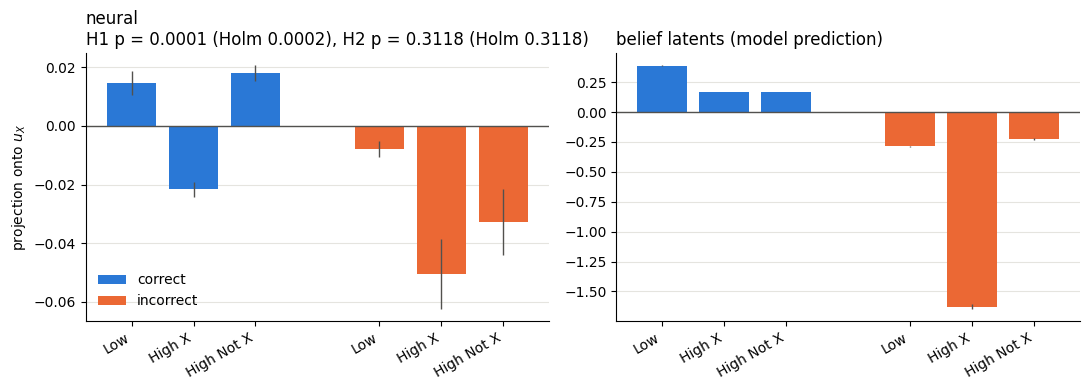

In [4]:
PARTITIONS = ["Low", "High X", "High Not X"]
# blue / orange rather than green / red: green / red fails the colorblind (deutan) separation check
OUTCOME_COLORS = {"cor": "#2a78d6", "inc": "#eb6834"}
OUTCOME_LABELS = {"cor": "correct", "inc": "incorrect"}

def plot_cells(ax, cells_df, title):
    df = cells_df.set_index("cell")
    for i, outcome in enumerate(["cor", "inc"]):
        x = np.arange(len(PARTITIONS)) + i * (len(PARTITIONS) + 1)
        rows = df.loc[[f"{outcome}/{p}" for p in PARTITIONS]]
        ax.bar(x, rows["mean"], yerr=rows["se"], width=0.8, color=OUTCOME_COLORS[outcome],
               linewidth=0, error_kw={"elinewidth": 1, "ecolor": "#52514e"},
               label=OUTCOME_LABELS[outcome])
    ticks = np.concatenate([np.arange(len(PARTITIONS)) + i * (len(PARTITIONS) + 1) for i in range(2)])
    ax.set_xticks(ticks)
    ax.set_xticklabels(PARTITIONS * 2, rotation=30, ha="right")
    ax.axhline(0, color="#52514e", linewidth=1)
    ax.grid(axis="y", color="#e5e4df", linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
    ax.set_title(title, loc="left")

def p_str(stats_df):
    s = stats_df.set_index("contrast")
    return ", ".join(f"{h} p = {s.loc[h, 'p']:.4f} (Holm {s.loc[h, 'p_holm']:.4f})" for h in ["H1", "H2"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_cells(axes[0], cells["neural"], f"neural\n{p_str(stats['neural'])}")
plot_cells(axes[1], cells["beliefs"], "belief latents (model prediction)")
axes[0].set_ylabel("projection onto $u_X$")
axes[0].legend(frameon=False, loc="lower left")
fig.tight_layout()

## White-noise check

With no signal, every p should be spread over (0, 1).

In [5]:
wn = pd.concat([read("white_noise", "stats", seed).assign(seed=seed) for seed in WHITE_NOISE_SEEDS])
wn.pivot(index="seed", columns="contrast", values="p").round(3)

contrast,H1,H2,control
seed,,,
1,0.000,0.008,1.0
2,0.000,0.679,1.0
3,0.000,0.698,1.0
4,0.000,0.376,1.0
42,0.001,0.064,1.0


## Counts

Test events per session, pooled over features.

In [6]:
events = read("neural", "events")
per_session = events.groupby(["session", "cell"]).size().unstack("cell").fillna(0)
order = [f"{o}/{p}" for o in ["cor", "inc"] for p in PARTITIONS]
pd.DataFrame({"median": per_session.median(), "min": per_session.min(),
              "sessions with 0": (per_session == 0).sum()}).loc[order]

,median,min,sessions with 0
cell,,,
cor/Low,104.0,14.0,0
cor/High X,102.0,14.0,0
cor/High Not X,101.5,9.0,0
inc/Low,109.0,13.0,0
inc/High X,6.0,0.0,1
inc/High Not X,5.5,0.0,4
